<h1>NAO Index ACC</h1>

![UFS-logo](../../../UFS-Logo-RGB-2csolidshorizontal-72dpi-min.png)

In [1]:
basedir = f'../../../..'

In [2]:
import os
import sys
import scipy
import xarray as xr

# Point to root directory of repository
root_dir = os.path.join(os.getcwd(), basedir)
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)
    
from src.datareader import datareader as dr
from src.util import util, stats, timeutil

import warnings
warnings.filterwarnings('ignore')

<h5>User Configurables</h5>

In [3]:
ufs_experiment = 'beta1'

In [4]:
ufs_var = 'prmsl'
era5_var = 'mean_sea_level_pressure'

In [5]:
time_range = ("1991-01-01", "2020-12-31T23")
initmonths = (3,4,5,11)

In [6]:
# For NAO, there are 2 reference locations:
region_1 = {'latmin': 65.0, 'lonmin': 331.2}
region_2 = {'latmin': 37.7, 'lonmin': 334.3}

<h5>Get SFS data</h5>

In [7]:
ufs_datasets = []  # List of datasets, one per initmonth

for this_initmonth in initmonths:
    this_initmonth = str(this_initmonth).zfill(2)
    this_filename = f"experiments/{ufs_experiment}/reforecast/{this_initmonth}/atm_monthly.zarr"
    ufs_datasets.append(dr.getDataReader(datasource='UFS', filename=this_filename, model='atm').dataset())

Reading data from s3://noaa-oar-sfsdev-pds/experiments/beta1/reforecast/03/atm_monthly.zarr
Reading data from s3://noaa-oar-sfsdev-pds/experiments/beta1/reforecast/04/atm_monthly.zarr
Reading data from s3://noaa-oar-sfsdev-pds/experiments/beta1/reforecast/05/atm_monthly.zarr
Reading data from s3://noaa-oar-sfsdev-pds/experiments/beta1/reforecast/11/atm_monthly.zarr


In [8]:
# Combine datasets and form into a DataReader object.
concat_ds = xr.concat(ufs_datasets, dim='init')
concat_ds = concat_ds.sortby('init')

ufs_data_reader = dr.getDataReader(datasource='UFS', filename=this_filename, model='atm')
ufs_data_reader.update(ds=concat_ds)
del concat_ds

Reading data from s3://noaa-oar-sfsdev-pds/experiments/beta1/reforecast/11/atm_monthly.zarr
Dataset updated.


<h5>Get ERA5 data</h5>

In [9]:
# Get ERA5 data
era5_data_reader = dr.getDataReader(datasource='ERA5')

No filename provided; deferring to default
Reading data from gs://gcp-public-data-arco-era5/ar/1959-2022-6h-512x256_equiangular_conservative.zarr


In [10]:
ufs_data_reader.describe(ufs_var)


Variable: prmsl
Dimensions: ('init', 'lead', 'member', 'lat', 'lon')
Shape: (139, 12, 11, 361, 720)
Attributes:


In [11]:
era5_data_reader.describe(era5_var)


Variable: mean_sea_level_pressure
Dimensions: ('time', 'lat', 'lon')
Shape: (92044, 256, 512)
Attributes:
  - long_name: Mean sea level pressure
  - short_name: msl
  - standard_name: air_pressure_at_mean_sea_level
  - units: Pa


<h5>Get the monthly climatology for nino 3.4</h5>

In [12]:
ufs_ds_1 = ufs_data_reader.retrieve(var=ufs_var,
                                    time=time_range,
                                    initmonths=initmonths,
                                    lat=region_1['latmin'],
                                    lon=region_1['lonmin'],
                                    ens_avg=True).load()  # load

ufs_ds_2 = ufs_data_reader.retrieve(var=ufs_var,
                                    time=time_range,
                                    initmonths=initmonths,
                                    lat=region_2['latmin'],
                                    lon=region_2['lonmin'],
                                    ens_avg=True).load()  # load

Taking Ensemble Average
Taking Ensemble Average


<h5>Get the corresponding ERA5 data</h5>

In [13]:
era5_ds_1 = era5_data_reader.retrieve(var=era5_var,
                lat=region_1['latmin'],
                lon=region_1['lonmin'])

era5_ds_2 = era5_data_reader.retrieve(var=era5_var,
                lat=region_2['latmin'],
                lon=region_2['lonmin'])

In [14]:
# Ensure that temporal domains perfectly match.
era5_ds_1 = timeutil.match_time_to_leads(verif_ds=era5_ds_1,
                                         ufs_ds=ufs_ds_1).load()  # load

era5_ds_2 = timeutil.match_time_to_leads(verif_ds=era5_ds_2,
                                         ufs_ds=ufs_ds_2).load()  # load

<h5>Calculate climatologies for each dataset (this may take a couple minutes)</h5>

In [15]:
ufs_stats_1 = stats.calc_climatology_anomaly(ufs_ds_1, area_mean=False, use_member_climatology=False)
ufs_stats_2 = stats.calc_climatology_anomaly(ufs_ds_2, area_mean=False, use_member_climatology=False)

In [16]:
era5_stats_1 = stats.calc_climatology_anomaly(era5_ds_1, area_mean=False)
era5_stats_2 = stats.calc_climatology_anomaly(era5_ds_2, area_mean=False)

<h5>Normalize the data.  z = (X - mu) / sigma</h5>

In [17]:
# Normalize UFS datasets
ufs_da_1 = stats.normalize(da=ufs_ds_1[ufs_var], stats=ufs_stats_1)
ufs_da_2 = stats.normalize(da=ufs_ds_2[ufs_var], stats=ufs_stats_2)

In [18]:
# Normalize VERIF datasets
era5_da_1 = stats.normalize(da=era5_stats_1['monthly_mean'], stats=era5_stats_1)
era5_da_2 = stats.normalize(da=era5_stats_2['monthly_mean'], stats=era5_stats_2)

<h2>Calculate NAO Index</h2>

<h5>Take difference between 2 locations and store result into new datasets</h5>

In [19]:
ufs_da_1 = ufs_da_1.squeeze(['lat', 'lon'])  # flatten
ufs_da_2 = ufs_da_2.squeeze(['lat', 'lon'])
era5_da_1 = era5_da_1.squeeze(['lat', 'lon'])
era5_da_2 = era5_da_2.squeeze(['lat', 'lon'])

In [20]:
ufs_ds_nao = (ufs_da_2 - ufs_da_1).to_dataset()
era5_ds_nao = (era5_da_2 - era5_da_1).to_dataset()

<h2>Calculate and Plot Anomaly Correlation Coefficient</h2>

<module 'matplotlib.pyplot' from '/home/thamzey/miniforge2/envs/ufs_py311/lib/python3.11/site-packages/matplotlib/pyplot.py'>

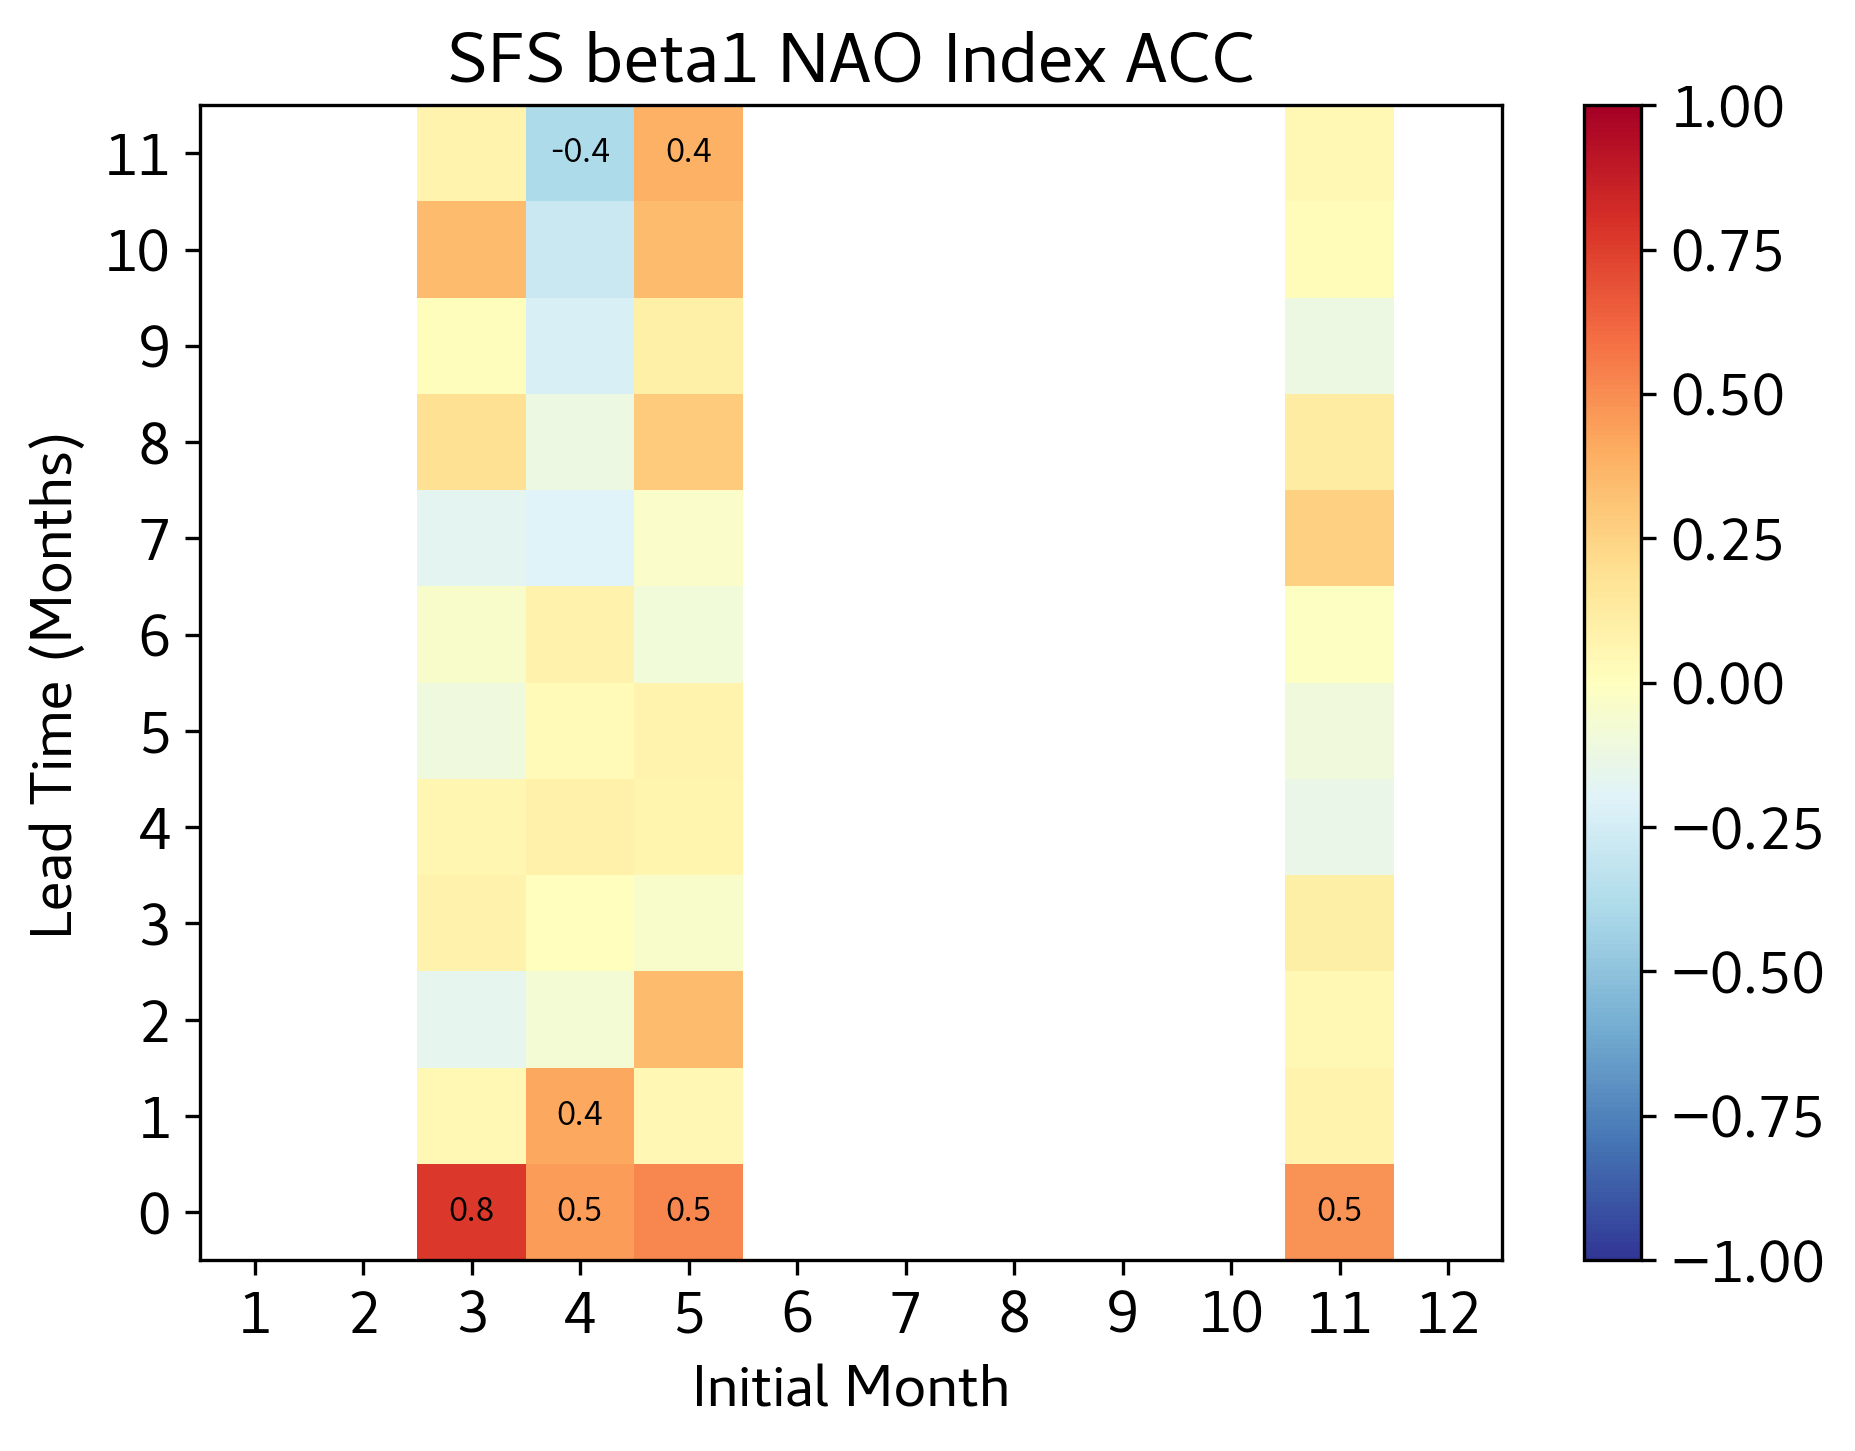

In [21]:
stats.plot_acc_heatmap(ufs_da=ufs_ds_nao[ufs_var],
                       verif_da=era5_ds_nao[era5_var],
                       title=f'SFS {ufs_experiment} NAO Index ACC',
                       sigalpha=0.05,
                       dpi=300)